# 09 · Raster change and multimodal interpretation

**Mission:** compute an illustrative water-index change, visualize uncertainty, and prepare a figure for Astra. Allow 40 minutes. Prerequisites: Labs 05 and 08.

**Run:** choose the Python (Pyodide) kernel in JupyterLite, then Run → Run All Cells. First use downloads Matplotlib. All training data are **SYNTHETIC** unless explicitly labeled LIVE. Downloads appear below and in `exports/`; the browser filesystem is separate from your computer. Each lab runs independently.

In [1]:
import sys
if sys.platform == "emscripten":
    import micropip
    await micropip.install("matplotlib")
import json, math
from pathlib import Path
from IPython.display import display, HTML
import matplotlib.pyplot as plt
from worldview_lab import (load, export, map_layer, chart_style, haversine_km,
    wilson_interval, shortest_times, freshness, normalize_quakes,
    validate_geojson, brief_request, validate_brief)
chart_style()

## Synthetic reflectance, not a satellite observation

Generate two 60 × 60 grids in a fictional local projected coordinate system with **100 m cells**. Green and near-infrared reflectance form `NDWI = (green − NIR)/(green + NIR)`. Mask cloud pixels before comparing dates. A threshold is an assumption; NDWI is not proof of flooding and is sensitive to land cover, atmosphere, and sensor characteristics.

In [2]:
import numpy as np
rng=np.random.default_rng(42)
y,x=np.mgrid[:60,:60]
water_before=(x-25)**2+(y-30)**2<100
water_after=(x-28)**2+(y-30)**2<210
def reflectance(water):
    green=np.where(water,.25,.16)+rng.normal(0,.012,water.shape)
    nir=np.where(water,.09,.31)+rng.normal(0,.012,water.shape)
    return (green-nir)/(green+nir)
before,after=reflectance(water_before),reflectance(water_after)
cloud=(x>39)&(y<18)
before=np.where(cloud,np.nan,before);after=np.where(cloud,np.nan,after)
THRESHOLD=.15
valid=np.isfinite(before)&np.isfinite(after)
new_water=valid&(before<=THRESHOLD)&(after>THRESHOLD)
area_km2=int(new_water.sum())*.1*.1
print(f'New threshold-positive area: {area_km2:.2f} km²; valid coverage {valid.mean():.1%}')

New threshold-positive area: 3.60 km²; valid coverage 90.0%


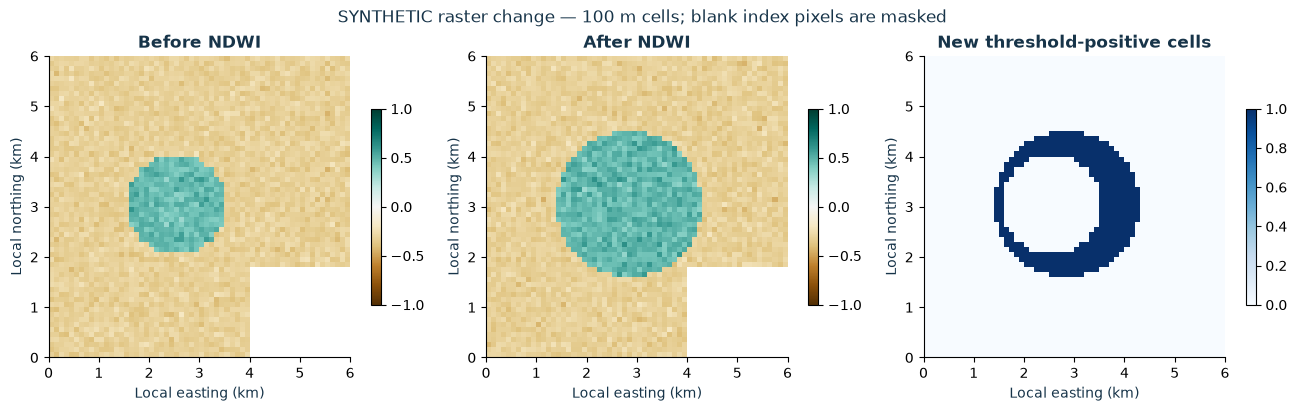

In [3]:
fig,axs=plt.subplots(1,3,figsize=(13,4),constrained_layout=True)
for ax,array,title in zip(axs,[before,after,new_water.astype(float)],['Before NDWI','After NDWI','New threshold-positive cells']):
    im=ax.imshow(array,origin='lower',extent=[0,6,0,6],cmap='BrBG' if 'NDWI' in title else 'Blues',vmin=-1 if 'NDWI' in title else 0,vmax=1)
    ax.set(title=title,xlabel='Local easting (km)',ylabel='Local northing (km)');fig.colorbar(im,ax=ax,shrink=.65)
fig.suptitle('SYNTHETIC raster change — 100 m cells; blank index pixels are masked')
Path('exports').mkdir(exist_ok=True);fig.savefig('exports/raster-change.png',dpi=140);plt.show()

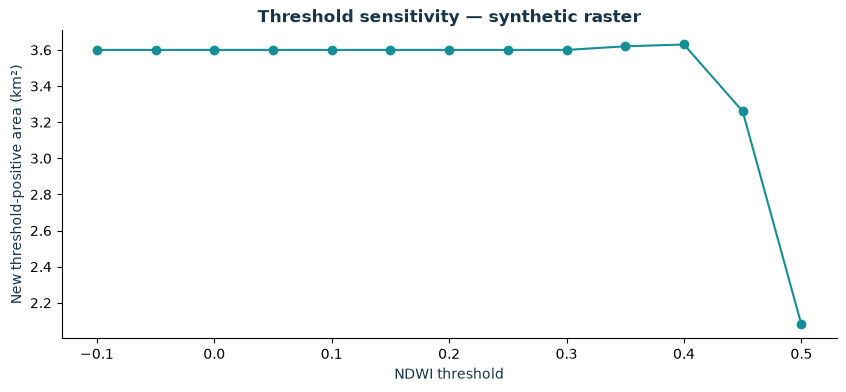

WindowsPath('exports/raster-evidence.json')

In [4]:
thresholds=np.linspace(-.1,.5,13)
areas=[float((valid&(before<=t)&(after>t)).sum())*.01 for t in thresholds]
fig,ax=plt.subplots();ax.plot(thresholds,areas,'o-');ax.set(xlabel='NDWI threshold',ylabel='New threshold-positive area (km²)',title='Threshold sensitivity — synthetic raster');plt.show()
export('raster-evidence.json',{'classification':'SYNTHETIC EXERCISE','evidence':[{'id':'RASTER-01','metric':'new_threshold_positive_area','value':area_km2,'unit':'km2','threshold':THRESHOLD,'cell_size_m':100}], 'limitations':['Synthetic reflectance','Clouds masked','Not georeferenced to real geography','Not a validated flood detector']})

## Vision lab

Download `exports/raster-change.png` from the file browser. With the Lab 08 runner, attach it using `--image` and the raster evidence JSON. Ask Astra to describe the visible change, explain the mask and threshold, and identify what requires ground verification. Check its description against the computed area.

**Try:** double the cell size to 200 m while keeping the same pixels. **Checkpoint:** the reported area multiplies by four, demonstrating why image dimensions alone cannot provide a physical area. Change the threshold and explain the stability or instability of the result.

## Sources and attribution

[USGS remote-sensing report](https://pubs.usgs.gov/publication/ofr20241029/full) provides context for green/NIR indices and their interpretive limits. NDWI is used for multiple band combinations in the literature; always name the bands. The green/NIR definition follows [McFeeters (1996), DOI](https://doi.org/10.1080/01431169608948714). [OpenAI vision guidance](https://developers.openai.com/api/docs/guides/images-vision) describes image input and limitations.

World View inspiration: [Kevin (Khoa) To, MIT](https://github.com/kevtoe/worldview). Original lab code, figures, and synthetic fixtures: JupyterLite WorldView contributors, MIT. See the [book references](https://jltobias.github.io/JupyterLite-WorldView/book/references.html) and repository notices for dependency and service terms.